# NK2R PDC 2025 榜单校准分析

**目的**：用 2025 届公开榜单（1590 条提交，其中 142 条经 AF3 预筛后合成实测）回答三个问题：
1. 组委会的 AF3 预筛到底按什么指标选人？（守门员函数还原）
2. 在实测集合内，哪些计算指标能把活性分子（EC50 可拟合 / <100 nM）与无活性分子分开？
3. 由此校准 binder-forge 的过滤阈值（同时服务 PDC 多肽与长江杯 VHH/minibinder 两个 campaign）

数据源：`data/external/2025_pep_design_comp_all_entries_with_synthesize_highlight.xlsx`（官网公开下载）

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
FIG = Path('figures'); FIG.mkdir(exist_ok=True)

DATA = Path('../data/external/2025_pep_design_comp_all_entries_with_synthesize_highlight.xlsx')
df = pd.read_excel(DATA)

EC50  = 'EC50 Value (nM)'
ACT2  = '% of Maximum Activation on NK2R (Peptide (500 μM)/NKA (10 μM))'
ACTNC = '% of Maximum Activation on NC (Peptide (500 μM)/NKA (10 μM))'
METRICS = ['iptm_AB((NK2R_Peptide))', 'iptm_AD((NK2R_NKA))', 'iptm', 'ptm',
           'ranking_score', 'mean_plddt_CA_all', 'mean_plddt_CA_chainB', 'fraction_disordered']

df['len']  = df['Amino acid Sequence'].str.len()
df['n_cys'] = df['Amino acid Sequence'].str.count('C')
df['tested'] = df['synthesize'].astype(str).eq('1')
df['hard_synth'] = df['synthesize'].astype(str).str.contains('Difficult')

t = df[df['tested']].copy()
t['active'] = t[EC50].notna()     # EC50 可拟合 = 有可测活性
t['hit100'] = t[EC50] < 100       # 赛事自身的高活性门槛

print(f'总提交 {len(df)} | 实测 {len(t)} | 难合成弃测 {df["hard_synth"].sum()}')
print(f'实测中: 有可测活性 {t["active"].sum()} ({t["active"].mean():.1%}) | EC50<100nM {int(t["hit100"].sum())} ({t["hit100"].mean():.1%})')

总提交 1590 | 实测 142 | 难合成弃测 7
实测中: 有可测活性 23 (16.2%) | EC50<100nM 9 (6.3%)


## 1. 官方预筛函数还原：142/1590 是如何被选中的？
对每项指标计算"被选中实测"的 AUC，并对比中位数。这直接刻画守门员行为。

In [2]:
sel, unsel = df[df['tested']], df[~df['tested'] & ~df['hard_synth']]
rows = []
for m in METRICS:
    rows.append({'metric': m,
                 'AUC(被选中)': round(roc_auc_score(df['tested'], df[m]), 3),
                 '选中中位数': round(sel[m].median(), 3),
                 '落选中位数': round(unsel[m].median(), 3)})
prescreen = pd.DataFrame(rows).sort_values('AUC(被选中)', ascending=False).reset_index(drop=True)
prescreen

,metric,AUC(被选中),选中中位数,落选中位数
0,iptm_AB((NK2R_Peptide)),0.974,0.910,0.300
1,mean_plddt_CA_chainB,0.955,84.144,40.389
2,iptm,0.542,0.700,0.700
3,mean_plddt_CA_all,0.507,78.503,78.438
4,ranking_score,0.504,0.790,0.790
5,ptm,0.491,0.710,0.720
6,fraction_disordered,0.425,0.180,0.180
7,iptm_AD((NK2R_NKA)),0.099,0.250,0.850


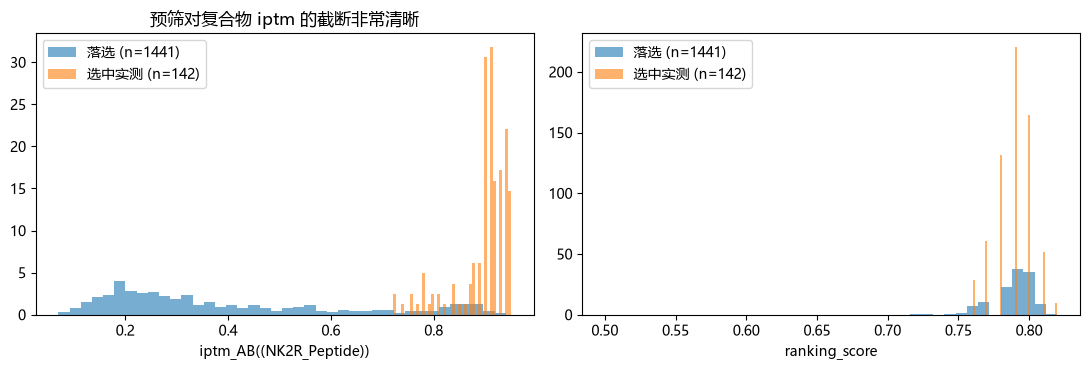

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, m in zip(axes, ['iptm_AB((NK2R_Peptide))', 'ranking_score']):
    ax.hist(unsel[m], bins=40, alpha=0.6, density=True, label=f'落选 (n={len(unsel)})')
    ax.hist(sel[m],  bins=40, alpha=0.6, density=True, label=f'选中实测 (n={len(sel)})')
    ax.set_xlabel(m); ax.legend()
axes[0].set_title('预筛对复合物 iptm 的截断非常清晰')
plt.tight_layout(); plt.savefig(FIG/'01_prescreen.png', dpi=130); plt.show()

## 2. 实测集合内：哪些指标与真实活性相关？
⚠️ 注意：实测集已经过了强预筛（指标取值范围被压缩），这里的 AUC 是**保守下界**。
命中定义：active = EC50 可拟合（23 条）；hit100 = EC50 < 100 nM（9 条）。

In [4]:
rows = []
for m in METRICS:
    rows.append({'metric': m,
                 'AUC_active': round(roc_auc_score(t['active'], t[m]), 3),
                 'AUC_hit100': round(roc_auc_score(t['hit100'], t[m]), 3),
                 'active中位': round(t.loc[t['active'], m].median(), 3),
                 'inactive中位': round(t.loc[~t['active'], m].median(), 3)})
disc = pd.DataFrame(rows).sort_values('AUC_active', ascending=False).reset_index(drop=True)
disc

,metric,AUC_active,AUC_hit100,active中位,inactive中位
0,iptm,0.783,0.834,0.710,0.700
1,ptm,0.778,0.857,0.720,0.710
2,ranking_score,0.751,0.824,0.800,0.790
3,mean_plddt_CA_all,0.694,0.603,78.907,78.453
4,mean_plddt_CA_chainB,0.634,0.705,86.341,83.513
5,iptm_AB((NK2R_Peptide)),0.595,0.647,0.920,0.910
6,fraction_disordered,0.594,0.650,0.180,0.180
7,iptm_AD((NK2R_NKA)),0.490,0.280,0.250,0.250


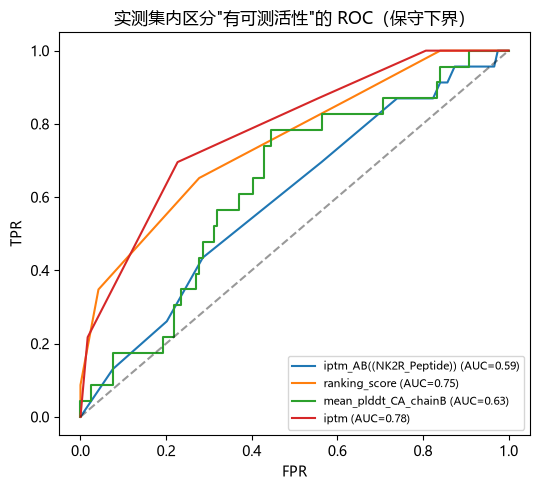

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for m in ['iptm_AB((NK2R_Peptide))', 'ranking_score', 'mean_plddt_CA_chainB', 'iptm']:
    fpr, tpr, _ = roc_curve(t['active'], t[m])
    ax.plot(fpr, tpr, label=f'{m} (AUC={roc_auc_score(t["active"], t[m]):.2f})')
ax.plot([0,1],[0,1],'k--',alpha=0.4); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('实测集内区分"有可测活性"的 ROC（保守下界）'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'02_roc_active.png', dpi=130); plt.show()

## 3. 阈值富集：iptm_AB 卡多高，命中率翻几倍？

In [6]:
base = t['hit100'].mean()
print(f'基准命中率(EC50<100nM): {base:.1%}\n')
print('iptm_AB 单指标富集:')
for cut in [0.5, 0.6, 0.7, 0.8, 0.9]:
    sub = t[t['iptm_AB((NK2R_Peptide))'] >= cut]
    if len(sub):
        print(f'  ≥{cut}: n={len(sub):3d} | hit100={int(sub["hit100"].sum())} | 命中率 {sub["hit100"].mean():.1%} | 富集 {sub["hit100"].mean()/base:.1f}x')
print('\n组合 (iptm_AB≥0.8 且 ranking_score≥阈值):')
for rs in [0.75, 0.8, 0.85]:
    sub = t[(t['iptm_AB((NK2R_Peptide))'] >= 0.8) & (t['ranking_score'] >= rs)]
    if len(sub):
        print(f'  rs≥{rs}: n={len(sub):3d} | hit100={int(sub["hit100"].sum())} | 命中率 {sub["hit100"].mean():.1%} | 富集 {sub["hit100"].mean()/base:.1f}x')

基准命中率(EC50<100nM): 6.3%

iptm_AB 单指标富集:
  ≥0.5: n=142 | hit100=9 | 命中率 6.3% | 富集 1.0x
  ≥0.6: n=142 | hit100=9 | 命中率 6.3% | 富集 1.0x
  ≥0.7: n=142 | hit100=9 | 命中率 6.3% | 富集 1.0x
  ≥0.8: n=131 | hit100=9 | 命中率 6.9% | 富集 1.1x
  ≥0.9: n=108 | hit100=9 | 命中率 8.3% | 富集 1.3x

组合 (iptm_AB≥0.8 且 ranking_score≥阈值):
  rs≥0.75: n=131 | hit100=9 | 命中率 6.9% | 富集 1.1x
  rs≥0.8: n= 46 | hit100=7 | 命中率 15.2% | 富集 2.4x


## 4. 激动率与脱靶：hit 的激活谱

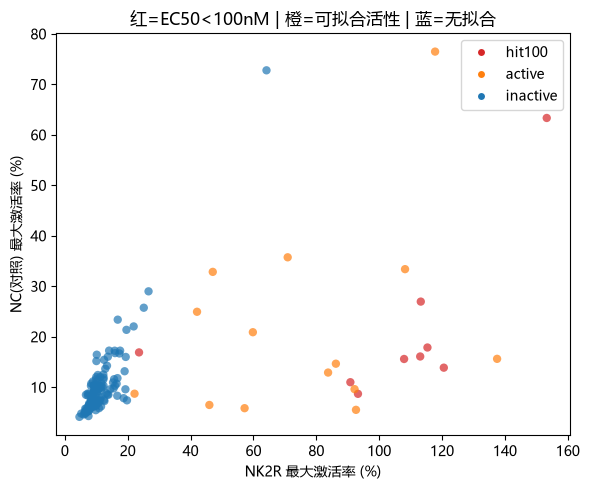

hit100 分子的 NK2R 激活率: [90.8, 115.4, 120.6, 23.6, 93.3, 113.1, 113.2, 107.9, 153.3]
hit100 分子的 NC 激活率 : [11.0, 17.9, 13.9, 16.9, 8.7, 16.1, 27.0, 15.6, 63.3]


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = np.where(t['hit100'], '#d62728', np.where(t['active'], '#ff7f0e', '#1f77b4'))
ax.scatter(t[ACT2], t[ACTNC], c=colors, alpha=0.7, edgecolors='none')
ax.set_xlabel('NK2R 最大激活率 (%)'); ax.set_ylabel('NC(对照) 最大激活率 (%)')
ax.set_title('红=EC50<100nM | 橙=可拟合活性 | 蓝=无拟合')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=c,label=l) for c,l in
                   [('#d62728','hit100'),('#ff7f0e','active'),('#1f77b4','inactive')]])
plt.tight_layout(); plt.savefig(FIG/'03_activation.png', dpi=130); plt.show()
print('hit100 分子的 NK2R 激活率:', t.loc[t['hit100'], ACT2].round(1).tolist())
print('hit100 分子的 NC 激活率 :', t.loc[t['hit100'], ACTNC].round(1).tolist())

## 5. 序列特征：环肽、药效团残留、长度
以及 7 条"难合成"弃测序列给了我们什么教训（可合成性过滤）。

In [8]:
t['disulfide'] = t['n_cys'] >= 2
t['nka_c_motif'] = t['Amino acid Sequence'].str.contains('F[YF][LM]M|CFYFLM|FVGLM', regex=True)
feat = pd.DataFrame({
    '特征': ['含二硫键对(C≥2)', 'NKA C端药效团样 motif', '长度>15aa'],
    'active占比': [t.loc[t['active'],'disulfide'].mean(), t.loc[t['active'],'nka_c_motif'].mean(), (t.loc[t['active'],'len']>15).mean()],
    'inactive占比': [t.loc[~t['active'],'disulfide'].mean(), t.loc[~t['active'],'nka_c_motif'].mean(), (t.loc[~t['active'],'len']>15).mean()],
}).set_index('特征').round(3)
print(feat)
print('\n活性分子长度分布:', t.loc[t['active'],'len'].describe().round(1).to_dict())
print('\n--- 7 条难合成弃测序列 ---')
print(df.loc[df['hard_synth'], ['Amino acid Sequence','len','n_cys','All Methods']].to_string(index=False))
print('\n各方法战绩(实测集):')
print(t.groupby('All Methods')['active'].agg(实测='count', 有活性='sum', 活性率='mean').round(2).sort_values('有活性', ascending=False).to_string())

                  active占比  inactive占比
特征                                    
含二硫键对(C≥2)           0.261       0.008
NKA C端药效团样 motif     0.522       0.000
长度>15aa              0.043       0.336

活性分子长度分布: {'count': 23.0, 'mean': 11.2, 'std': 3.6, 'min': 6.0, '25%': 9.0, '50%': 10.0, '75%': 15.0, 'max': 17.0}

--- 7 条难合成弃测序列 ---
                    Amino acid Sequence  len  n_cys       All Methods
                     GMAFQSTGLLVNAIVSCP   18      1      AlphaFold2/3
   MKMVTSLERAKRIAKKCGIDDPDLINTISLSLILLR   36      1       RFdiffusion
                     HLAFQAIGLLVNPVVTCP   18      1      AlphaFold2/3
 SDEEIWAAACAEQEARVGAKVCGRIDKIRACGGYFFLP   38      3       RFdiffusion
     KTLLEVAKELGNDLLIKALEKAKELGLEYFVGLM   34      0 Custom generative
SVLEEKIRTLSAWTGISLEKAREIIEKLGLDTRVFVGLM   39      0 Custom generative
MIFLRVRGLDAEEMKRWREKAKKLSKETGIKYRVGPYFG   39      0       RFdiffusion

各方法战绩(实测集):
                               实测  有活性   活性率
All Methods                                 
Custom

## 6. 结论与阈值建议
汇总到 `docs/analysis/nk2r_2025_calibration_report.md`，并落盘 JSON 供 funnel 引用。

In [9]:
import json
summary = {
  'prescreen_gate': '官方预筛近似硬门槛: iptm_AB 与 ranking_score(见 AUC 表)',
  'recommended_peptide_filter': {
      'iptm_complex_screen': 0.6, 'iptm_complex_select': 0.8,
      'ranking_score_select': 0.8,
      'note': '预筛是晋级条件; 实测集内指标区分度为保守下界, 仍建议双预测器一致'
  },
  'sequence_design': {
      'cyclization': '活性分子显著富集二硫键环肽(C>=2)',
      'length_sweet_spot': '活性分子中位长度见 cell5',
      'synthesizability': '多Cys/长疏水段有难合成弃测风险, 需前置过滤'
  }
}
Path('figures/recommended_thresholds.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "prescreen_gate": "官方预筛近似硬门槛: iptm_AB 与 ranking_score(见 AUC 表)",
  "recommended_peptide_filter": {
    "iptm_complex_screen": 0.6,
    "iptm_complex_select": 0.8,
    "ranking_score_select": 0.8,
    "note": "预筛是晋级条件; 实测集内指标区分度为保守下界, 仍建议双预测器一致"
  },
  "sequence_design": {
    "cyclization": "活性分子显著富集二硫键环肽(C>=2)",
    "length_sweet_spot": "活性分子中位长度见 cell5",
    "synthesizability": "多Cys/长疏水段有难合成弃测风险, 需前置过滤"
  }
}
